<div class="alert alert-block alert-info">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Hola Edgar soy Santiago y hoy reviso tu proyecto ConnectaTel. Guia rapida de colores:

Por favor no muevas, edites ni elimines mis comentarios. Empecemos! 🚀
</div>
<div class="alert alert-block alert-success">Verde: algo esta bien hecho.</div>
<div class="alert alert-block alert-warning">Amarillo: tip o recomendacion, no bloquea la aprobacion.</div>
<div class="alert alert-block alert-danger">Rojo: necesita correccion antes de aprobar.</div>


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Hola! El diagnostico general esta bien encaminado y la limpieza (age/city/reg_date), MAR (exploracion con crosstab), agregacion, merge, histogramas, boxplots, IQR y segmentacion estan bien implementados en el codigo. Encontre 4 puntos que si necesitan correccion:

- **Numero incorrecto en el diagnostico de `city` (seccion 2.2):** dice "649 marcados como NaN" - el numero real, segun tu propio output de la seccion 2.1, es 469.
- **Diagnostico de MAR sin completar (seccion 3.2):** la celda de exploracion con `pd.crosstab` esta bien hecha, pero el bloque de texto para escribir tu conclusion se quedo con el texto de plantilla sin responder.
- **Dos histogramas con el titulo incorrecto (seccion 5.1):** el de `cant_llamadas` y el de `cant_minutos_llamada` tienen el titulo "Distribucion de la cantidad de mensajes..." (copiado del histograma anterior) en vez de "llamadas" y "minutos en llamada" respectivamente. Las etiquetas de los ejes si estan correctas, solo el titulo quedo mal.
- **GitHub:** el mismo patron recurrente en varias entregas de este proyecto - placeholder sin reemplazar y URL suelta en una celda de codigo.

Tambien dejo un tip no bloqueante sobre el insight ejecutivo, que le vendria bien mas cifras concretas.

</div>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [4]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

`.info()` correcto para los tres datasets.
</div>

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users

print("Cantidad de valores nulos:")
print(users.isna().sum())

print("\nProporción de valores nulos:")
print((users.isna().mean() * 100).round(2))

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [12]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())

print("\nProporción de valores nulos:")
print((usage.isna().mean() * 100).round(2))

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen calculo de nulos para `users` y `usage` por separado.
</div>

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

En users la columna churn_date se podria eliminar por el porcentaje mayor al 80% de valores nulos pero se deberia investigar primero.


En Usage, se revisaron los valores faltantes, las columnas con pocos valores pueden imputarse pero estos se deben revisasr primero.





### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buena exploracion, identificando correctamente el `-999` en `age` y los valores minimos de 0 en `duration`/`length`.
</div>

- La columna `user_id` es una variable unica que sirve como identificador.
- La columna `age` la columna age es la edad por lo que es imposible que tenga un minimo de -999 se podria marcar como sentinel o invalida esa edad.

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`ambas son vairbles unicas que sirven como identificadores.
- Las columnas 'duration' y 'lenght' tienen un minimo de 0 lo cual vienen siendo valores invalidos revisar esos valores para ver que significan si tomarlos como sentinels.
- Las columnas 'duration' y 'lenght' tienen un valor maximo muy superior a su media, tambien poseen valores faltantes.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
   print(f"\nValores únicos en {col}:")
   print(users[col].value_counts(dropna=False))




Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Este numero no coincide con tu propio calculo de la seccion 2.1: ahi tu `isna().sum()` mostro 469 valores nulos en `city`, no 649. Por favor corrige la cifra para que el diagnostico sea consistente con tu propio resultado.
</div>

- La columna `city` tiene 96 valores unicos como ? y 469 marcados como NaN que son valores invalidos.
- La columna `plan` no tiene valores invalidos o nulos, se podria usar para la segmentacion

In [16]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Tip para tu proximo proyecto: la rubrica tambien sugiere encapsular esta exploracion repetida en una funcion reutilizable, por ejemplo `def valores_invalidos(df, columnas): ...`. No bloquea esta entrega.
</div>

- La columna `type` no tiene valores invalidos o nulos, se podria usar para la segmentacion.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  R= En la columna de 'duration', 'lenght',  'age' y 'city'
- ¿Qué acción tomarías?
  R= En el caso de las columnas 'age' y 'city' se deben tomar los valores como -999 y ? para pasarlos a valores NAN para ver el impacto sobre los resultados finales Y en el caso de 'duration' y 'lenght' Tienen unos valores en 0 que son valores extraños los cuales de deberian analizar primero apra ver que accion tomar de ellos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")# completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce")# completa el código

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen diagnostico de fechas, con `errors='coerce'` y correcta identificacion de los registros de 2026.
</div>

En `reg_date`, del 2022 al 2024 son valores totalmente estables y muy parecidos se toman en cuenta solo hsata el 2024 por lo que los pocos registros del 2026 se deben marcar como no validos para nuestros resultados.

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, tiene varias fechas del 2024 que sirven para el analisis y 50 que estan marcadas como NaN por lo que no se tomaran en cuenta. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  R= Si en 'reg_date' aparecen datos del 2026 que estan fuera de rango y en 'date' aparecen valores como NaN
- ¿Qué harías con ellas?
  R= En el caso de 'reg_date' no se tomaran en cuenta los valores del 2026 al estar fuera de rango y de 'date' marcarlas como invalidas y documentar esos registros por que estan de esa manera.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Las tres correcciones estan perfectamente implementadas: mediana de `age` excluyendo el sentinel, `city` con `pd.NA` real, y `reg_date` corregido con `>2024`.
</div>

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
pd.crosstab(
    usage['type'],
    usage['duration'].isna(),
    margins=True
)

duration,False,True,All
type,,,
call,17908,0,17908
text,16,22076,22092
All,17924,22076,40000


In [25]:
# Verificación MAR en usage (Missing At Random) para length
pd.crosstab(
    usage['type'],
    usage['length'].isna(),
    margins=True
)

length,False,True,All
type,,,
call,12,17896,17908
text,22092,0,22092
All,22104,17896,40000


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

La exploracion con `pd.crosstab` (celdas 41-42) esta muy bien hecha y deja clarisimo el patron MAR. Pero esta celda se quedo con el texto de plantilla sin responder (Haz doble clic aqui y escribe...). Escribe tu conclusion, por ejemplo: los nulos de duration y length dependen completamente de type (llamadas nunca tienen length, mensajes nunca tienen duration) - es un patron MAR estructural, no un error de captura, asi que se mantienen como nulos.
</div>

Cuando el registro es de tipo call, el campo duration almacena cuánto duró la llamada, mientras que length permanece vacío porque no corresponde. Cuando el registro es de tipo text, el campo length almacena el tamaño del mensaje, y duration permanece vacío porque no es pertinente.

Pero también se detectaron algunos registros inconsistentes: 16 textos tienen duration registrada y 12 llamadas tienen length registrada. Estos casos deben revisarse porque no siguen la lógica esperada del dataset.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left") 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Agregacion, renombrado y merge (`how='left'`) todo correcto.
</div>

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True).mul(100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

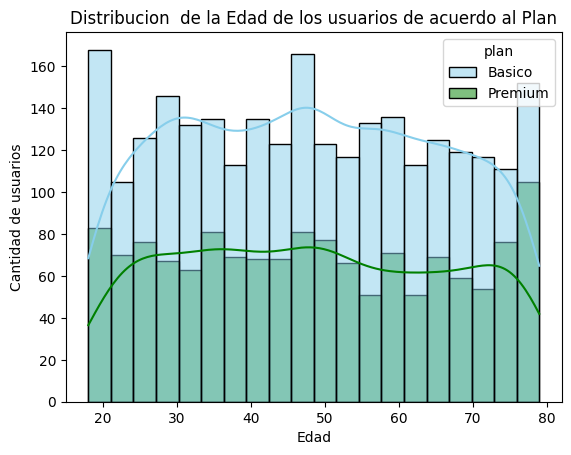

In [31]:
# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile, x="age", hue="plan", bins=20, palette=["skyblue", "green"],kde=True
)

plt.title("Distribucion  de la Edad de los usuarios de acuerdo al Plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen histograma, con titulo, etiquetas e insight correctos.
</div>

💡Insights: 
- La Distribución de  usuarios se ve bastante uniforme ahi mas usuarios del plan basico que del plan premium, el plan basico tiene picos de usarios entre los principios de los 20, mediados de los 50  y gente casi llegando a los 80 mientras que el plan premium tiene su pico mas alto de gente llegando a los 80.

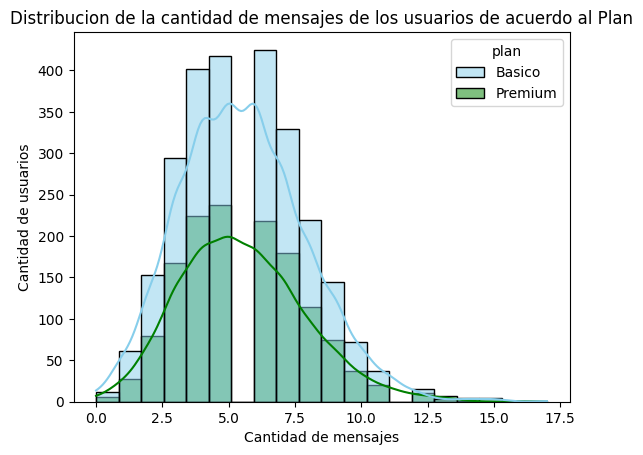

In [32]:
# Histograma para visualizar la cant_mensajes

sns.histplot(
    data=user_profile, x="cant_mensajes", hue="plan", bins=20, palette=["skyblue", "green"],kde=True
)

plt.title("Distribucion de la cantidad de mensajes de los usuarios de acuerdo al Plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen histograma de mensajes, con titulo, etiquetas e insight correctos.
</div>

💡Insights: 
- La distribucion tienen sesgo a la derecha, existen mas usuarios con plan basico que premium, tiene una alta distribucion entre 4,5 y  7 en cantidad de mensajes tanto en basico como en premium.

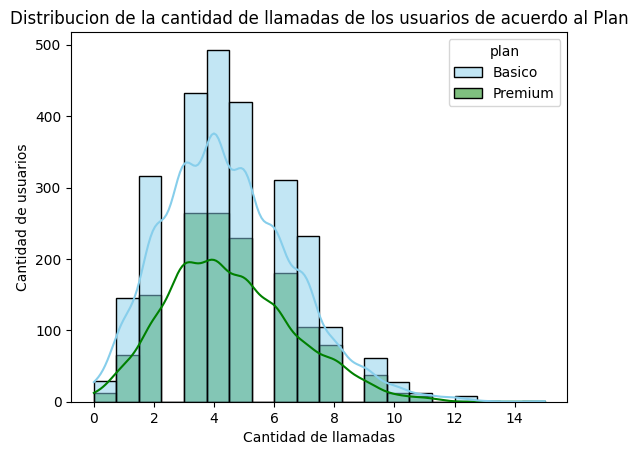

In [33]:
# Histograma para visualizar la cant_llamadas

sns.histplot(
    data=user_profile, x="cant_llamadas", hue="plan", bins=20, palette=["skyblue", "green"],kde=True
)

plt.title("Distribucion de la cantidad de llamadas de los usuarios de acuerdo al Plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

El titulo de este grafico dice "Distribucion de la cantidad de mensajes..." pero el grafico muestra `cant_llamadas` (llamadas) - parece que se copio el titulo del histograma anterior sin actualizarlo. La etiqueta del eje X si dice correctamente "Cantidad de llamadas". Corrige el titulo a "Distribucion de la cantidad de llamadas de los usuarios de acuerdo al Plan".
</div>

💡Insights: 
- Distribución con sesgo a la derecha ahi mas usuarios de plan basico que premium, la cantidad de llamadas tiene su pico en 4.

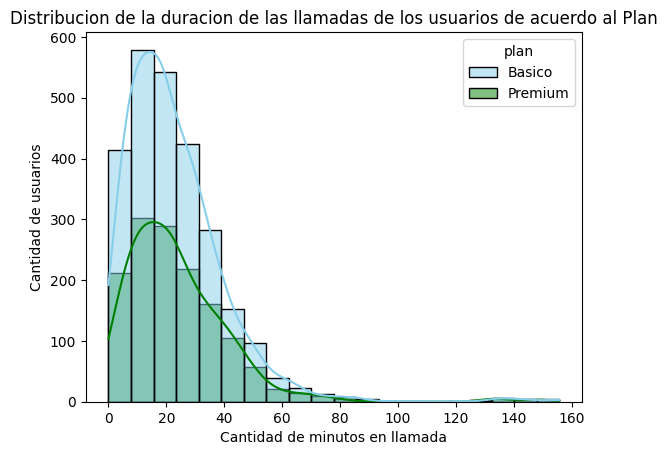

In [34]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile, x="cant_minutos_llamada", hue="plan", bins=20, palette=["skyblue", "green"],kde=True
)

plt.title("Distribucion de la duracion de las llamadas de los usuarios de acuerdo al Plan")
plt.xlabel("Cantidad de minutos en llamada")
plt.ylabel("Cantidad de usuarios")
plt.show()

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Mismo problema aqui: el titulo dice "Distribucion de la cantidad de mensajes..." pero el grafico muestra `cant_minutos_llamada`. Corrige el titulo a "Distribucion de la cantidad de minutos en llamada de los usuarios de acuerdo al Plan".
</div>

💡Insights: 
- La distribucion tiene un sesgo muy pronunciado a la derecha, el plan basico es mayor al premium, la mayoria tiene una cantidad de minutos en llamada es entre los 10 y 20 minutos aprox.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

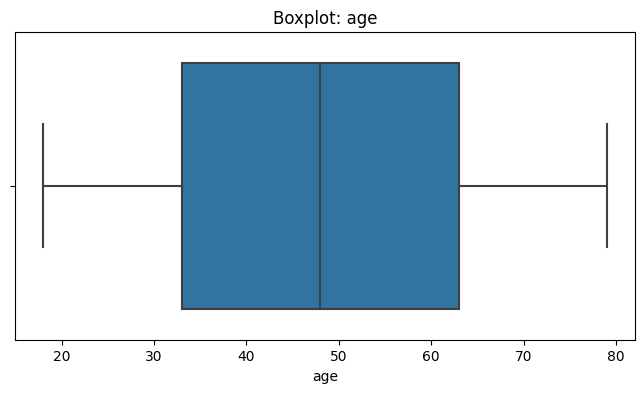

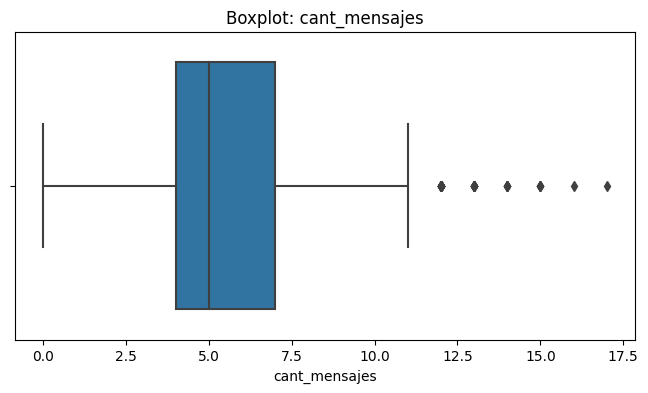

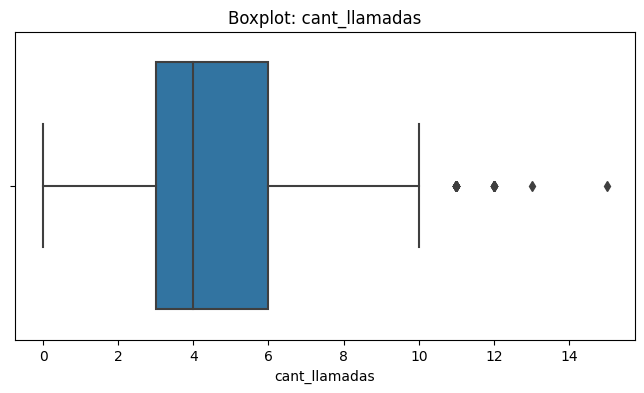

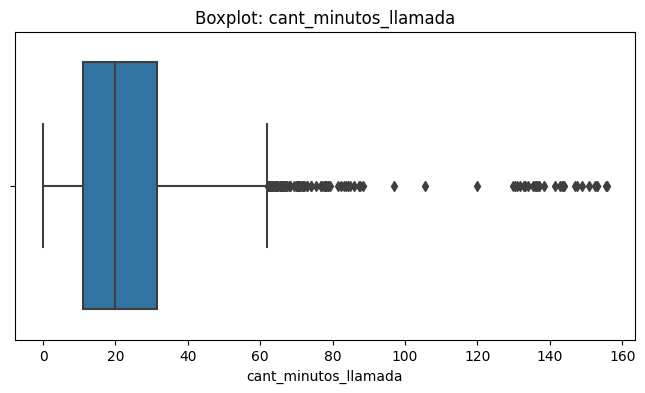

In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Los 4 boxplots estan completos y bien generados en un `for`.
</div>

💡Insights: 
- Age: No presenta outliners  
- cant_mensajes: Si presenta unos pocos outliners se detectan unos pocos usuarios con una cantidad de mensajes por encima del rango esperado.
- cant_llamadas: Si presenta unos pocos outliners varios usuarios con una cantidad de llamadas por encima del rango esperado.
- cant_minutos_llamada: Presenta muchos outliners en los es un comportamiento mucho mayor al esperado

In [38]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    IQR = q3 - q1
    limite_superior = q3 + 1.5 * IQR
    
    outliers = user_profile[user_profile[col] > limite_superior]
    
    print(f"\nVariable: {col}")
    print(f"Q1 =: {q1}")
    print(f"Q3 =: {q3}")
    print(f"IQR =: {IQR}")
    print(f"Límite superior =: {limite_superior}")
    print(f"Máximo =: {user_profile[col].max()}")
    print(f"Cantidad de outliers superiores =: {outliers.shape[0]}")


Variable: cant_mensajes
Q1 =: 4.0
Q3 =: 7.0
IQR =: 3.0
Límite superior =: 11.5
Máximo =: 17.0
Cantidad de outliers superiores =: 46

Variable: cant_llamadas
Q1 =: 3.0
Q3 =: 6.0
IQR =: 3.0
Límite superior =: 10.5
Máximo =: 15.0
Cantidad de outliers superiores =: 30

Variable: cant_minutos_llamada
Q1 =: 11.12
Q3 =: 31.415
IQR =: 20.295
Límite superior =: 61.8575
Máximo =: 155.69
Cantidad de outliers superiores =: 109


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Calculo de IQR completo y muy bien impreso: Q1, Q3, IQR, limite superior, maximo y conteo de outliers, todo claro para las 3 columnas.
</div>

In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Se recomienda mantener outliner ya que estos no alteran mucho los datos y sirve para reprentar a los usuarios que tienen alto uso de mensajeria.
- cant_llamadas:Se recomienda mantener outliner ya que estos no alteran mucho los datos y sirve para reprentar a los usuarios que tienen alto uso de llamadas.
- cant_minutos_llamada: Se recomienda mantener, de momento para investigar por que a pesar de que esta muy por encima de lo esperado, se debe tener evidencia de error.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [41]:
# Crear columna grupo_uso

user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [43]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
      user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Ambas segmentaciones correctas, con los umbrales exactos que piden las instrucciones.
</div>

In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

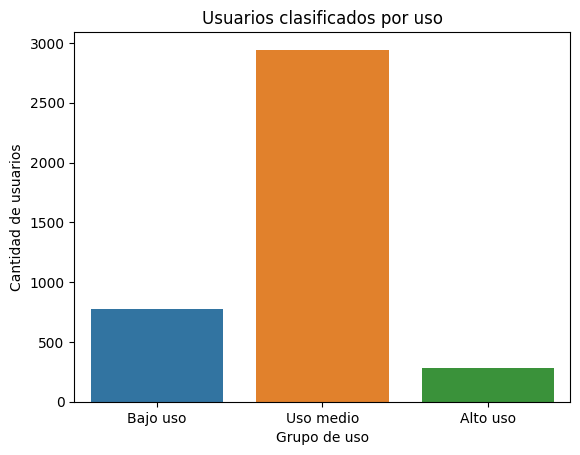

In [45]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso']
)

plt.title('Usuarios clasificados por uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

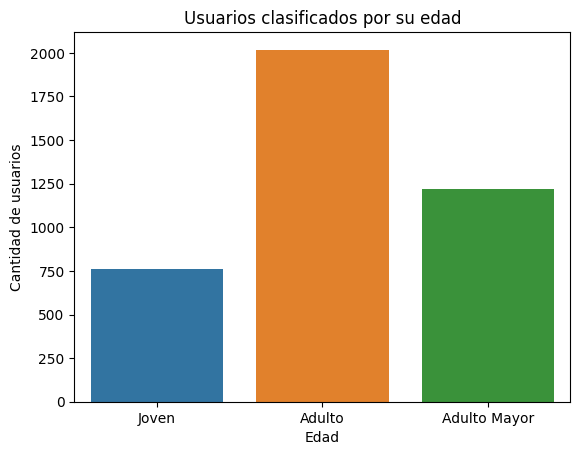

In [46]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor']
)

plt.title('Usuarios clasificados por su edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Ambos countplots completos, con `order=` explicito, titulo y etiquetas.
</div>


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
   R=
  *La columna de 'age' de 'Users' tenia sentinels de -999.
  *En 'city' habia registros como '?' un valor invalido que luego fueron cambiados a Nan.
  *En 'reg_date' habia registros con la fecha del 2026 siendo el maximo para nosotros 2024.
  *En 'Date' habia valores nulos.
  *En duration y length los nulos dependen principalmente de type. Para llamadas, duration aplica y length queda nulo. Para mensajes, length aplica y duration queda nulo. Se detectaron algunos registros inconsistentes.
  
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
   R=
   *Por edad La mayoria de los usuarios son Adultos por lo que deberiamos de concentrar la estrategia en esa parte.
   *Por uso La mayoria de los usuaior tienen un uso medio lo cual es un comportamiento estable y esperado.
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
   R=
   *Los segmentos de adulto y de y de uso medio al ser la mayoria de los usuarios.

   
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
   R= Encontre patrones de uso extremo en 'cant_minutos_llamada', deben mantenerse y tomarse en cuenta ya que representan a los usuarios de mayor ueso y son perfectamente estudiables y un area de oportunidad.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
  R=Crear campañas para mejor a los usuarios de bajo uso y hacia los jovenes tambien para no perder el publico a futuro y aumentar la cantidad de usuarios.
  Mejorar la captura de datos donde se encontraron sentinels. E investigar un poco mejor lo de los usuario de uso extremo.
  Mejorar la experiencia de usuario de medio uso para ver si podriamos aumentar los de alto uso.
  
✍️ **Escribe aquí tu análisis ejecutivo:**

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

El insight cubre los cuatro bloques que pide la rubrica y tiene buenas ideas de negocio (atraer al segmento joven, investigar el uso extremo), pero le faltan cifras concretas en casi todas las secciones - por ejemplo, en vez de "la mayoria de los usuarios son Adultos", conviene decir "el 55% de los usuarios son Adultos" (o el porcentaje real de tu segmentacion). Lo mismo aplica a los problemas de datos (cuantifica cada uno con su porcentaje) y a los segmentos de uso. No bloquea la aprobacion, pero mejoraria mucho la seccion.
</div>

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna de 'age' de 'Users' tenia sentinels de -999.
- En 'city' habia registros como '?' un valor invalido que luego fueron cambiados a Nan.
- En 'reg_date' habia registros con la fecha del 2026 siendo el maximo para nosotros 2024.
- En 'Date' habia valores nulos.
- En duration y length los nulos dependen principalmente de type. Para llamadas, duration aplica y length queda nulo. Para mensajes, length aplica y duration queda nulo. Se detectaron algunos registros inconsistentes.


🔍 **Segmentos por Edad**
- Por edad La mayoria de los usuarios son Adultos por lo que deberiamos de concentrar la estrategia en esa parte.
- Se podria hacer alguna estrategia para atraer a los jovenes ya que este sector se encuentra algo bajo en comparacion. 


📊 **Segmentos por Nivel de Uso**
- Por uso La mayoria de los usuaior tienen un uso medio lo cual es un comportamiento estable y esperado.
- Se deberia buscar una manera de aumentar el uso de la linea existen casos en los cuales ahi uso extremo que se podrian estudiar para aumentar el indice normal de uso.


➡️ Esto sugiere que ...
*Coonectatel tiene una base de cliente en su mayoria adultos y con un eso medio, lo cual se podria considerar un comportamiento estable y bastante promedio. Ahora esto es bueno pero se podria buscar maneras de aumentar tanto el tipo de publico a sectores como los jovenes ya que estos tienen mas tendencia al uso de electronicos que los adultos mayores y tambien aumentar el promedio de uso.

💡 **Recomendaciones**
- Crear campañas para mejor a los usuarios de bajo uso y hacia los jovenes tambien para no perder el publico a futuro y aumentar la cantidad de usuarios.
- Mejorar la captura de datos donde se encontraron sentinels. E investigar un poco mejor lo de los usuario de uso extremo.
- Mejorar la experiencia de usuario de medio uso para ver si podriamos aumentar los de alto uso.
  

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `https://github.com/edguirei014-lang/Telecom-Analisys/tree/main`

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Dos problemas aqui, el mismo patron que he visto en otras entregas de este proyecto:

1. El placeholder `LINK a tu repo aqui` nunca se reemplazo por tu link real.
2. La URL real quedo pegada en una celda de codigo en vez de en el link de Markdown - si intentas ejecutar esa celda, te daria un `SyntaxError`.

Corrige asi:

```markdown
Link a repositorio publico del proyecto: [Ver repositorio en GitHub](https://github.com/edguirei014-lang/Telecom-Analisys)
```

Y elimina la celda de codigo con la URL suelta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen trabajo de base - limpieza, agregacion, IQR y segmentacion estan bien implementados en el codigo. Pero todavia no esta listo para aprobar por 4 puntos:

1. Numero incorrecto en el diagnostico de city (dice 649, el real es 469).
2. Diagnostico de MAR sin completar - la exploracion esta bien, falta la conclusion escrita.
3. Dos histogramas con titulo incorrecto (dicen "mensajes" en vez de "llamadas"/"minutos en llamada").
4. GitHub - placeholder sin reemplazar + URL suelta en celda de codigo.

Como tip no bloqueante: agrega cifras concretas al insight ejecutivo.

Con esos 4 ajustes, el proyecto queda listo para aprobar. Animo! 💪
</div>